In [254]:
from typing import Callable
import re
import pandas as pd
import numpy as np
from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

train_keys = {
    "kl": float,
    "lrMultiplier": float,
    "loss": float,
    "entropy": float,
    "explVarOld": float,
    "explVarNew": float,
}

eval_keys = {
    "numPlayouts": int,
    "win": int,
    "lose": int,
    "tie": int,
    "avgCurrStarted": float,
}

train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open("results.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

In [255]:
eval_df.describe()

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
count,60,60.000000,60.000000,60.000000,60.0,60.000000
mean,2023-12-27 04:24:17.461800448,1683.333333,6.350000,3.650000,0.0,0.513333
min,2023-12-26 21:10:24.906000,1000.000000,0.000000,0.000000,0.0,0.300000
25%,2023-12-26 22:24:01.080499968,1000.000000,4.750000,1.000000,0.0,0.400000
50%,2023-12-27 04:19:24.857499904,1000.000000,7.000000,3.000000,0.0,0.500000
75%,2023-12-27 10:23:50.048750080,3000.000000,9.000000,5.250000,0.0,0.600000
max,2023-12-27 11:50:39.496000,3000.000000,10.000000,10.000000,0.0,0.900000
std,NaN,873.172021,2.880825,2.880825,0.0,0.151228


In [256]:
train_df.describe()

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
count,2990,2990.000000,2990.000000,2990.000000,2990.000000,2990.000000,2990.000000
mean,2023-12-27 04:21:21.720377344,0.025243,0.094957,1.535910,0.920599,0.236136,0.256192
min,2023-12-26 21:06:27.423000,0.004770,0.088000,0.769310,0.461860,-0.030000,-0.026000
25%,2023-12-26 22:20:39.567000064,0.017070,0.088000,1.234412,0.662142,0.167000,0.181000
50%,2023-12-26 23:32:10.339500032,0.022385,0.088000,1.375565,0.754890,0.247000,0.270000
75%,2023-12-27 10:22:41.494749952,0.029880,0.088000,1.790825,1.137830,0.309000,0.334750
max,2023-12-27 11:49:35.216000,0.158010,0.667000,4.453110,3.520380,0.637000,0.729000
std,NaN,0.012614,0.039291,0.426596,0.384397,0.095237,0.101285


In [257]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(eval_df['avgCurrStarted'].std() * n_total_games))

round_fairness = eval_df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 600 games played in total, distributed as: [308 - z * 91, 308 + z * 91]


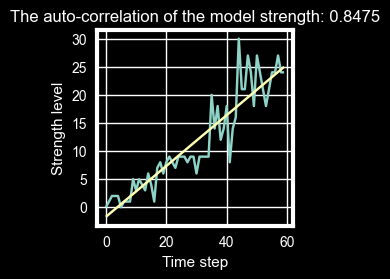

In [266]:
# Difficulty estimation

eval_df["strength"] = ((eval_df["win"] + eval_df["tie"] / 2) * eval_df["numPlayouts"] / 1000).round(2)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = np.arange(len(eval_df)).reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

axes = eval_df["strength"].plot()
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
axes.plot(x_axis, list(map(strength_estimator, x_axis)))
axes.set_xlabel('Time step')
axes.set_ylabel('Strength level')
plt.show(axes)

In [287]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")


[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training


In [288]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

loss_significance = .6
entropy_significance = .6

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one


[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward


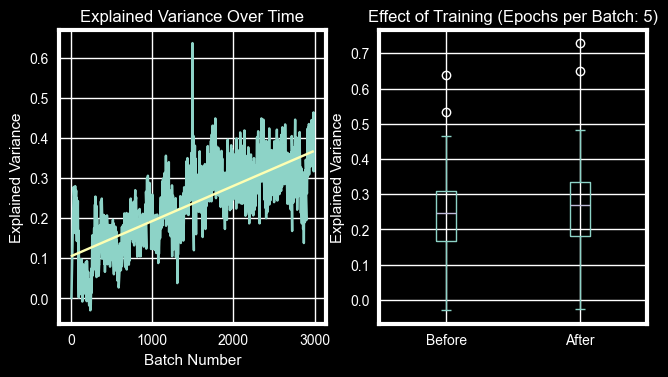

In [301]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .7
expl_var_difference_significance = .01

expl_var_corr = autocorr(train_df, "explVarOld")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

expl_var_difference = (train_df["explVarNew"] - train_df["explVarOld"]).mean()
if expl_var_difference < expl_var_difference_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {expl_var_difference:.4f} < {expl_var_difference_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1)

expl_var_lr = LinearRegression()
expl_var_lr.fit(x_axis, train_df["explVarOld"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
ax1 = train_df["explVarOld"].plot(ax=axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, x_axis)))

expl_var_difference_stats = train_df[["explVarOld", "explVarNew"]]
ax2 = expl_var_difference_stats.plot(kind="box", ax=axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_ylabel(f"Explained Variance")
ax2.set_xticklabels(["Before", "After"])

plt.show()

In [260]:
train_df.corr().loc["timestamp"]

timestamp       1.000000
kl             -0.173238
lrMultiplier   -0.088778
loss           -0.747370
entropy        -0.721569
explVarOld      0.780263
explVarNew      0.797760
Name: timestamp, dtype: float64